In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

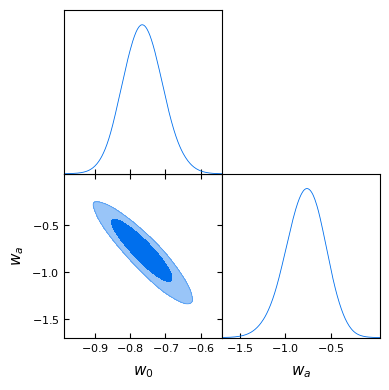

In [2]:
from getdist import plots, loadMCSamples


samples = loadMCSamples("data/chainDESY/chain")

g = plots.get_subplot_plotter()
g.triangle_plot(
    [samples],
    ["w", "wa"],
    filled=True
)

g.export("desi_w_wa.pdf")

In [3]:
omega_0 = samples.getParams().wa
omega_a = samples.getParams().w

In [8]:
def S_prime(z, S, w, chi):
    # A = (1+z)^3 chi + 1
    A = (1 + z) ** 3 * chi + 1

    # B = 1 + [1-calS^2] (1+z)^3 chi
    B = 1 + (1 - S ** 2) * (1 + z) ** 3 * chi

    # S'(z)
    dS_dz = -(3 / 2) * (S) / (1 + z) * \
            (w * B + S) / A

    return dS_dz


def w_cpl(z, w0, wa):
    return w0 + wa * z / (1 + z)


z_span = (0, 4)
z_eval = np.linspace(0, 4, 200)
S0 = [1]


sols = []




for w0, wa in zip(omega_0, omega_a):

    sol = solve_ivp(
        lambda z, S: S_prime(
            z, S, w_cpl(z, w0, wa), chi=32/68
        ),
        z_span,
        S0,
        t_eval=z_eval
    )

    sols.append(sol.y[0])



np.int64(22509)

In [15]:
best_index = np.argmin(samples.getParams().chi2)
omega_0_best =omega_0[best_index]
omega_a_best = omega_a[best_index]
best_fit = solve_ivp(
        lambda z, S: S_prime(
            z, S, w_cpl(z, omega_0_best, omega_a_best), chi=32/68
        ),
        z_span,
        S0,
        t_eval=z_eval)

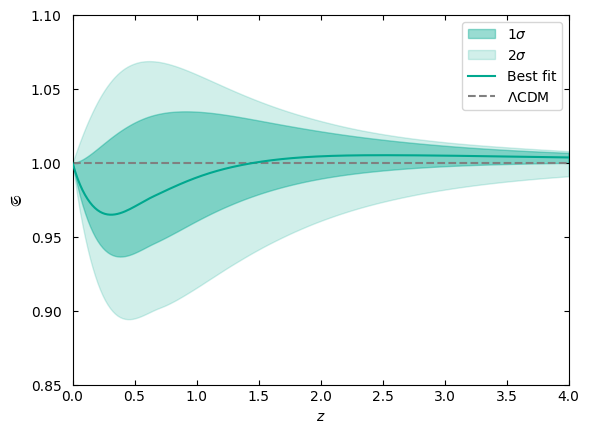

'Data: DESI Y3 BAO + DES-SN Y5 + Planck 2018 low-l TT + Planck 2020 LoLLiPoP low-l E + Planck 2020 HiLLiPOP TTTEEE + ACT DR6 CMB lensing'

In [24]:
S = np.array(sols)

sigma2 = np.percentile(S, [2.5, 97.5], axis=0)
sigma1 = np.percentile(S, [16, 84], axis=0)

plt.fill_between(z_eval, *sigma1, color="#00A88F", alpha=0.40, label=r"$1\sigma$")
plt.fill_between(z_eval, *sigma2, color="#00A88F", alpha=0.18, label=r"$2\sigma$")

plt.plot(
    z_eval,
    best_fit.y[0],
    color="#00A88F",
    linewidth=1.5,
    label="Best fit",
    zorder=5
)

plt.axhline(
    y=1,
    color="gray",
    linestyle="--",
    linewidth=1.5,
    label=r"$\Lambda$CDM"
)

plt.legend()
plt.xlabel(r"$z$")
plt.ylabel(r"$\mathfrak{S}$")
plt.tick_params(axis='y', pad=8)
plt.legend(frameon=True)
plt.ylim(0.850,1.1)
plt.xlim(0,4)

plt.tick_params(direction="in", top=True, right=True)

plt.savefig(
    "mainOutput.pdf",
    format="pdf",
    bbox_inches="tight"
)


plt.show()
"Data: DESI Y3 BAO + DES-SN Y5 + Planck 2018 low-l TT + Planck 2020 LoLLiPoP low-l E + Planck 2020 HiLLiPOP TTTEEE + ACT DR6 CMB lensing"


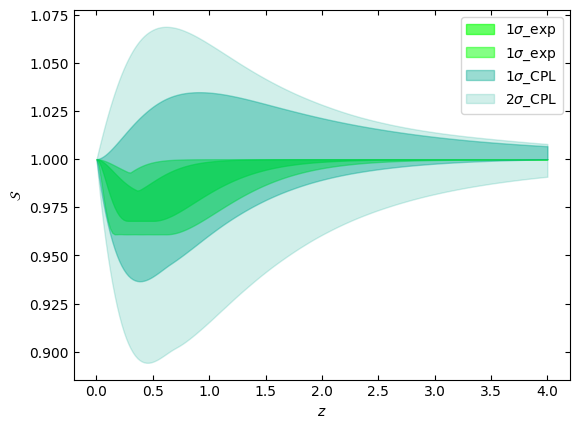

In [25]:
delta = np.linspace(0.391-0.114, 0.391+0.114, 20)
beta = np.linspace(-0.025-0.007, -0.025+0.007, 20)
s_exp = []
for b in beta:
    for d in delta:
        s_exp.append( 1 + b/(d**2)*z_eval**2*np.exp(2*(1-z_eval/d)))

delta_2sigma = np.linspace(0.391-2*0.114, 0.391+2*0.114, 20)
beta_2sigma = np.linspace(-0.025-2*0.007, -0.025+2*0.007, 20)
s_exp_2sigma = []
for b in beta_2sigma:
    for d in delta_2sigma:
        s_exp_2sigma.append( 1 + b/(d**2)*z_eval**2*np.exp(2*(1-z_eval/d)))


sigma1_exp = np.percentile(s_exp, [0, 100], axis=0)
plt.fill_between(z_eval, *sigma1_exp, color="#00FF00", alpha=0.60, label=r"$1\sigma$_exp")

sigma2_exp = np.percentile(s_exp_2sigma, [0, 100], axis=0)
plt.fill_between(z_eval, *sigma2_exp, color="#00FF00", alpha=0.48, label=r"$1\sigma$_exp")



plt.fill_between(z_eval, *sigma1, color="#00A88F", alpha=0.40, label=r"$1\sigma$_CPL")
plt.fill_between(z_eval, *sigma2, color="#00A88F", alpha=0.18, label=r"$2\sigma$_CPL")

plt.xlabel(r"$z$")
plt.ylabel(r"$\mathcal{S}$")

plt.legend(frameon=True)
plt.tick_params(direction="in", top=True, right=True)
plt.show()

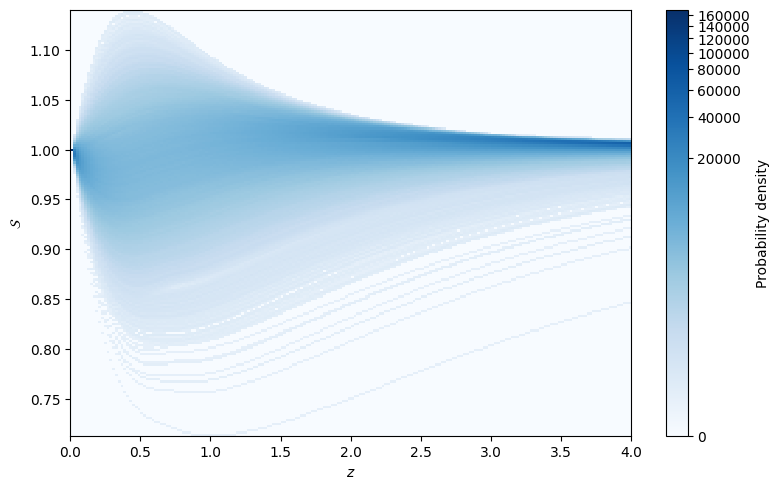

In [21]:
plt.figure(figsize=(8, 5))

from matplotlib.colors import PowerNorm

plt.hist2d(
    np.tile(z_eval, S.shape[0]),
    S.ravel(),
    bins=[200, 200],
    cmap="Blues",
    norm=PowerNorm(0.2),
    cmin=0
)


plt.axhline(-1, color="black", linestyle="--", linewidth=1.5)

plt.xlabel(r"$z$")
plt.ylabel(r"$\mathcal{S}$")
plt.colorbar(label="Probability density")

plt.tight_layout()
plt.show()